# Introducción y Configuración
En este proyecto construimos un Asesor de IA con dos objetivos principales. El primero es analizar la demanda de habilidades en el mercado de TI utilizando el dataset "LinkedIn Job Postings (2023–2024)" https://www.kaggle.com/datasets/arshkon/linkedin-job-postings , el cual contiene aproximadamente 124,000 ofertas laborales. El segundo objetivo es predecir el salario de un desarrollador empleando el dataset "Stack Overflow Developer Survey 2023", que incluye alrededor de 89,000 registros de información sobre profesionales del desarrollo https://www.kaggle.com/datasets/stackoverflow/stack-overflow-2023-developers-survey. Este NoteBook trabajará el segundo objetivo

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Definir la ruta del archivo
file_path = "../../datasets/stack overflow/stack_overflow_2023.csv"

# Cargar el dataset
try:
    df = pd.read_csv(file_path)
    print("¡Dataset cargado exitosamente!")
    print(f"Forma del dataset (filas, columnas): {df.shape}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {file_path}")
    print("Por favor, verifica la ruta y vuelve a intentarlo.")

¡Dataset cargado exitosamente!
Forma del dataset (filas, columnas): (89184, 84)


## Descripción estadística del salario anual en USD


--- Descripción Estadística de 'ConvertedCompYearly' (Salario Anual USD) ---
count    4.801900e+04
mean     1.031101e+05
std      6.814188e+05
min      1.000000e+00
25%      4.390700e+04
50%      7.496300e+04
75%      1.216410e+05
max      7.435143e+07
Name: ConvertedCompYearly, dtype: float64


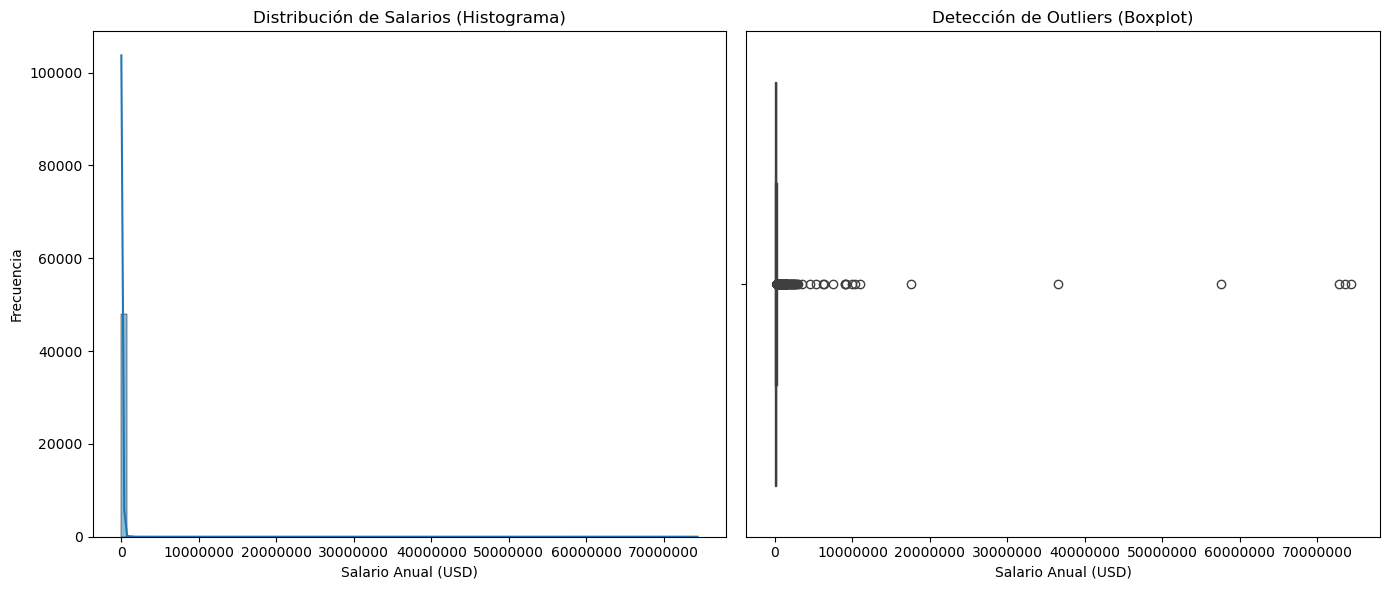

In [5]:
# Asegurarnos de que la columna es numérica, tratando errores
if 'ConvertedCompYearly' in df.columns:
    df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

    # 1. Descripción estadística
    print("\n--- Descripción Estadística de 'ConvertedCompYearly' (Salario Anual USD) ---")
    # Usamos .describe() para obtener la media, mediana (50%), min, max
    print(df['ConvertedCompYearly'].describe())

    # 2. Visualización: Histograma y Boxplot
    # Esto nos mostrará el sesgo y los valores atípicos (outliers)
    
    plt.figure(figsize=(14, 6))

    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(df['ConvertedCompYearly'].dropna(), kde=True, bins=100)
    plt.title('Distribución de Salarios (Histograma)')
    plt.xlabel('Salario Anual (USD)')
    plt.ylabel('Frecuencia')
    plt.ticklabel_format(style='plain', axis='x') # Evitar notación científica

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df['ConvertedCompYearly'])
    plt.title('Detección de Outliers (Boxplot)')
    plt.xlabel('Salario Anual (USD)')
    plt.ticklabel_format(style='plain', axis='x')

    plt.tight_layout()
    plt.show()

else:
    print("Error: La columna 'ConvertedCompYearly' no se encuentra en el dataset.")

### Diagnóstico
- **Media ($103,110) > Mediana ($74,963):** Esto confirma un fuerte sesgo positivo. Los salarios altos están "inflando" el promedio.

- **std (Desviación Estándar) de $681,418:** Una desviación estándar que es 6.6 veces más grande que la media ($103k) es enorme. Indica que los datos tienen una variabilidad extrema.

- **min de $1.00 y max de $74,351,430:** El max de $74 millones es un error o un dato anómalo que distorsionará nuestro modelo de regresión.

### Tratamiento de Outliers (Filtrado) y Transformación Logarítmica
Establecer filtros: Un mínimo de $1,000 USD anuales (para eliminar los $1) y un máximo de $1,000,000 USD anuales. (Un salario de $74M es imposible, pero $1M es un tope superior razonable para los salarios más altos de la industria).

Después de filtrar, la distribución seguirá estando sesgada. Para corregir esto, aplicaremos una Transformación Logarítmica. Esto "comprimirá" los valores altos y "expandirá" los bajos, haciendo que la distribución se parezca más a una campana (distribución normal), lo cual es ideal para los modelos de regresión lineal.

Filas originales con salario: 48019
Filas después de filtrar outliers: 47275

--- Descripción Estadística del Salario (Log-Transformado) ---
count    47275.000000
mean        11.103452
std          0.964933
min          6.908755
25%         10.723752
50%         11.225257
75%         11.719948
max         13.815512
Name: Log_ConvertedCompYearly, dtype: float64


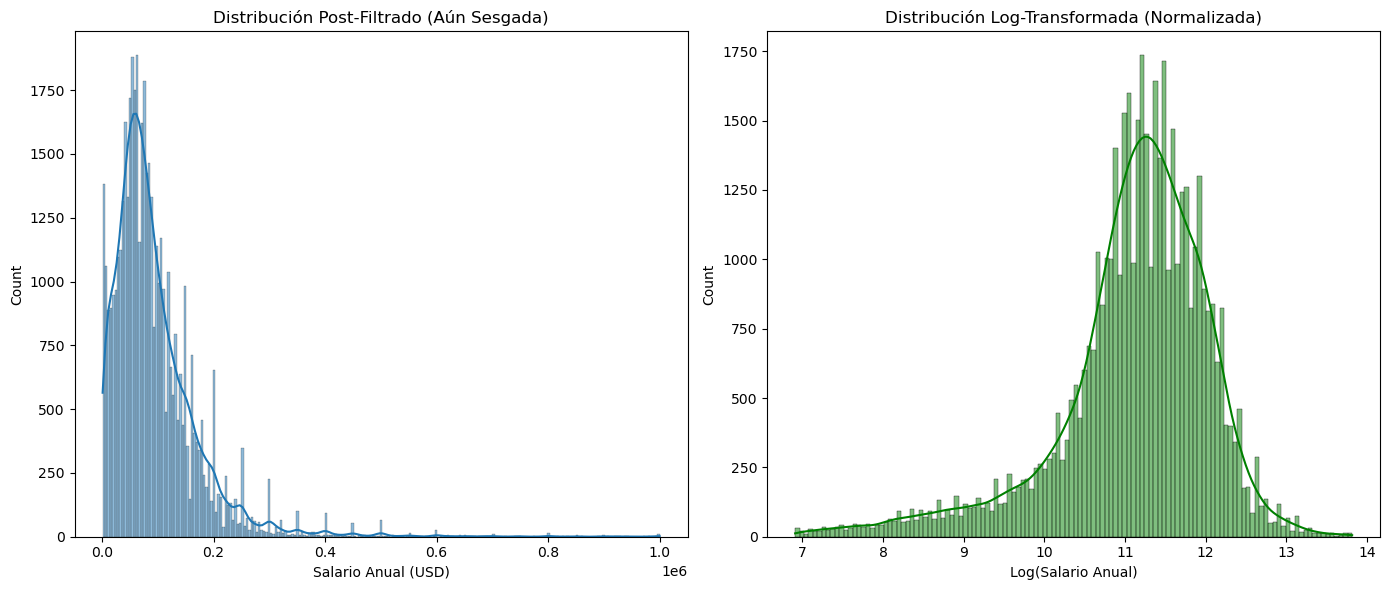

In [6]:
import numpy as np

# --- Fase 2: Preprocesamiento de la Variable Objetivo ---

# 1. Copiar el DataFrame para mantener el original (buena práctica)
df_limpio = df.copy()

# 2. Definir los límites (Tratamiento de Outliers)
SALARIO_MIN = 1000
SALARIO_MAX = 1000000

# 3. Filtrar el DataFrame
# Primero, filtramos los que SÍ tienen salario (no son NaN)
df_limpio = df_limpio[df_limpio['ConvertedCompYearly'].notna()]
# Aplicamos nuestros filtros de min y max
df_limpio = df_limpio[
    (df_limpio['ConvertedCompYearly'] >= SALARIO_MIN) &
    (df_limpio['ConvertedCompYearly'] <= SALARIO_MAX)
]

print(f"Filas originales con salario: {df['ConvertedCompYearly'].notna().sum()}")
print(f"Filas después de filtrar outliers: {len(df_limpio)}")

# 4. Transformación Logarítmica (Escalado Logarítmico)
# Usamos np.log1p (log(1+x)) que maneja valores 0 de forma segura
df_limpio['Log_ConvertedCompYearly'] = np.log1p(df_limpio['ConvertedCompYearly'])

print("\n--- Descripción Estadística del Salario (Log-Transformado) ---")
print(df_limpio['Log_ConvertedCompYearly'].describe())


# --- Visualización de la Transformación ---
plt.figure(figsize=(14, 6))

# Salario original (ya filtrado)
plt.subplot(1, 2, 1)
sns.histplot(df_limpio['ConvertedCompYearly'], kde=True)
plt.title('Distribución Post-Filtrado (Aún Sesgada)')
plt.xlabel('Salario Anual (USD)')

# Salario con transformación logarítmica
plt.subplot(1, 2, 2)
sns.histplot(df_limpio['Log_ConvertedCompYearly'], kde=True, color='green')
plt.title('Distribución Log-Transformada (Normalizada)')
plt.xlabel('Log(Salario Anual)')

plt.tight_layout()
plt.show()

## Preprocesamiento de Habilidades 
Veamos cuántos valores faltantes tiene y cuáles son las habilidades más comunes.


--- Análisis de Habilidades (LanguageHaveWorkedWith) ---
Filas con datos de habilidades: 47143 / 47275
Filas sin datos de habilidades (NaN): 132

Filas restantes después de eliminar NaN de habilidades: 47143

--- Top 20 Habilidades Más Comunes ---
LanguageHaveWorkedWith
JavaScript                 30249
SQL                        24485
HTML/CSS                   24246
Python                     21331
TypeScript                 20235
Bash/Shell (all shells)    16266
C#                         13482
Java                       12916
PHP                         8314
C++                         8072
PowerShell                  6896
Go                          6816
C                           6335
Rust                        5352
Kotlin                      4308
Ruby                        3500
Dart                        2383
Lua                         2280
Swift                       2248
Groovy                      1989
Name: count, dtype: int64


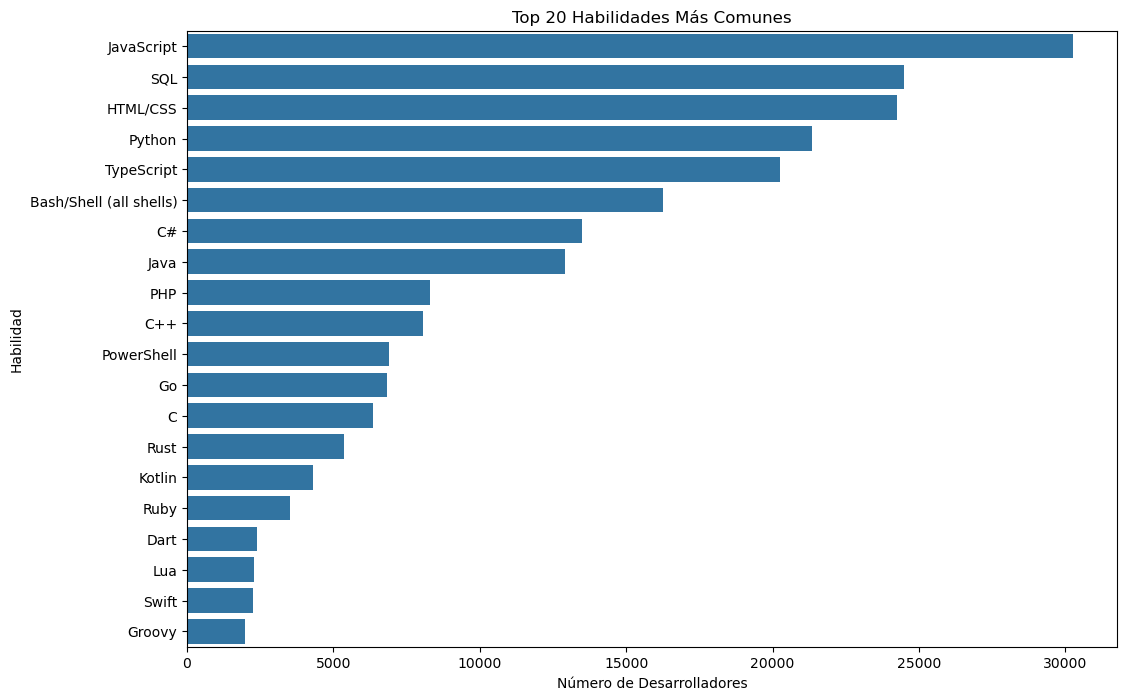

In [7]:
# --- Fase 1 y 2: EDA y Preprocesamiento de Habilidades ---

# 1. Analizar valores faltantes en 'LanguageHaveWorkedWith'
print("\n--- Análisis de Habilidades (LanguageHaveWorkedWith) ---")
faltantes_habilidades = df_limpio['LanguageHaveWorkedWith'].isna().sum()
total_filas = len(df_limpio)
print(f"Filas con datos de habilidades: {total_filas - faltantes_habilidades} / {total_filas}")
print(f"Filas sin datos de habilidades (NaN): {faltantes_habilidades}")

# 2. Preprocesamiento: Decidimos eliminar filas sin habilidades
# Si no reportan habilidades, no podemos usarlos en el recomendador.
df_limpio = df_limpio.dropna(subset=['LanguageHaveWorkedWith'])
print(f"\nFilas restantes después de eliminar NaN de habilidades: {len(df_limpio)}")

# 3. EDA: Encontrar las habilidades más comunes
# Usamos .split(';') para separar las cadenas y .value_counts() para contarlas
habilidades_series = df_limpio['LanguageHaveWorkedWith'].str.split(';').explode()
conteo_habilidades = habilidades_series.value_counts()

print("\n--- Top 20 Habilidades Más Comunes ---")
print(conteo_habilidades.head(20))

# 4. Visualización de las habilidades más comunes
plt.figure(figsize=(12, 8))
sns.barplot(x=conteo_habilidades.head(20).values, y=conteo_habilidades.head(20).index)
plt.title('Top 20 Habilidades Más Comunes')
plt.xlabel('Número de Desarrolladores')
plt.ylabel('Habilidad')
plt.show()

## Codificación de Variables 
Si creamos una columna para cada habilidad, podríamos terminar con cientos de columnas (alta dimensionalidad). Muchas de esas habilidades (como Groovy, en el puesto 20) son menos comunes y pueden no agregar mucho valor predictivo, pero sí agregan "ruido".

In [10]:
import pandas as pd
import numpy as np

# --- 1. Codificación de Habilidades (Tu lista de Demanda de LinkedIn) ---
print("--- Procesando Habilidades (One-Hot Encoding) ---")

# Tu lista validada de habilidades demandadas
skills_demandadas = [
    'python', 'amazon web services', 'microsoft azure', 'go', 'oracle java',
    'c', 'r', 'javascript', 'linux', 'c++', 'git', 'c#', 'kubernetes',
    'react', 'docker', 'google cloud platform', 'tableau', 'nosql', 'unix',
    'node.js', 'servicenow', 'typescript', 'vmware', 'github', 'ada',
    'bash', 'mysql', 'scala', 'spring boot', 'postgresql', 'sas',
    'mongodb', 'figma', 'gitlab', 'perl', 'selenium', 'ruby',
    'pytorch', 'swift', 'tensorflow', 'php', 'redis', 'microsoft sql server'
]

# Mapeo flexible para asegurar coincidencias en Stack Overflow
# (Clave: Tu lista -> Valor: Texto a buscar en SO)
mapeo_busqueda = {
    'amazon web services': 'aws', # Busca 'aws' dentro del string
    'microsoft azure': 'azure',
    'oracle java': 'java',
    'google cloud platform': 'google', # 'google cloud' o 'gcp'
    'bash': 'bash',
    'c++': 'c++',
    'node.js': 'node',
    'react': 'react'
}

# 1.1 Crear la "Sopa de Habilidades" (Uniendo todas las columnas relevantes)
cols_tech = [
    'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith', 'ToolsTechHaveWorkedWith', 'MiscTechHaveWorkedWith',
    'OpSysPersonal use'
]
# Solo usamos las que existen en el df
cols_existentes = [c for c in cols_tech if c in df_limpio.columns]

# Creamos una sola columna con todo el texto en minúsculas
df_limpio['All_Skills_Soup'] = df_limpio[cols_existentes].fillna('').agg(';'.join, axis=1).str.lower()

# 1.2 Crear las columnas binarias
for skill in skills_demandadas:
    # Definimos qué texto buscar (usamos el mapeo o el nombre original)
    termino_busqueda = mapeo_busqueda.get(skill, skill)
    col_name = f"Skill_{skill.replace(' ', '_').replace('.', '')}" # Nombre limpio de columna
    
    # Búsqueda robusta: si el término está en la "sopa", es un 1
    df_limpio[col_name] = df_limpio['All_Skills_Soup'].apply(lambda x: 1 if termino_busqueda in x else 0)

print(f"¡Habilidades codificadas! Total features de skills: {len(skills_demandadas)}")


# --- 2. Procesamiento de Años de Experiencia (YearsCodePro) ---
print("\n--- Procesando Experiencia (YearsCodePro) ---")

# Limpiar valores de texto como 'Less than 1 year' o 'More than 50 years'
df_limpio['YearsCodePro'] = df_limpio['YearsCodePro'].replace('Less than 1 year', 0.5)
df_limpio['YearsCodePro'] = df_limpio['YearsCodePro'].replace('More than 50 years', 50)

# Convertir a numérico y manejar NaNs (Imputación con la Mediana [cite: 136])
df_limpio['YearsCodePro'] = pd.to_numeric(df_limpio['YearsCodePro'], errors='coerce')
mediana_exp = df_limpio['YearsCodePro'].median()
df_limpio['YearsCodePro'] = df_limpio['YearsCodePro'].fillna(mediana_exp)

print(f"Experiencia procesada. Mediana imputada: {mediana_exp} años.")


# --- 3. Codificación de Nivel Educativo (Label Encoding) ---
# Usamos Label Encoding porque hay una jerarquía 
print("\n--- Procesando Educación (EdLevel) ---")

mapeo_edu = {
    'Something else': 0,
    'Primary/elementary school': 1,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 2,
    'Some college/university study without earning a degree': 3,
    'Associate degree (A.A., A.S., etc.)': 4,
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 5,
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 6,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 7
}

df_limpio['EdLevel_Code'] = df_limpio['EdLevel'].map(mapeo_edu)
# Llenar faltantes con el valor más común (Moda) o un valor medio (Bachelor)
df_limpio['EdLevel_Code'] = df_limpio['EdLevel_Code'].fillna(5) 


# --- 4. Codificación de País (Top 15 + Others) ---
print("\n--- Procesando País (Top 15 One-Hot) ---")
# Agrupamos los países con pocos datos en 'Other' para reducir ruido
top_countries = df_limpio['Country'].value_counts().head(15).index
df_limpio['Country_Grouped'] = df_limpio['Country'].apply(lambda x: x if x in top_countries else 'Other')

# One-Hot Encoding para el país 
df_paises = pd.get_dummies(df_limpio['Country_Grouped'], prefix='Country', dtype=int)
df_limpio = pd.concat([df_limpio, df_paises], axis=1)

print("Procesamiento completado.")
print(f"Forma final del DataFrame: {df_limpio.shape}")

--- Procesando Habilidades (One-Hot Encoding) ---
¡Habilidades codificadas! Total features de skills: 43

--- Procesando Experiencia (YearsCodePro) ---
Experiencia procesada. Mediana imputada: 8.0 años.

--- Procesando Educación (EdLevel) ---

--- Procesando País (Top 15 One-Hot) ---
Procesamiento completado.
Forma final del DataFrame: (47143, 147)


In [11]:
# Revisar correlaciones de las nuevas Skills con el salario (Log)
correlaciones = df_limpio.corr(numeric_only=True)['Log_ConvertedCompYearly'].sort_values(ascending=False)

print("--- Top 10 Variables correlacionadas positivamente con el Salario ---")
print(correlaciones.head(10))

print("\n--- Top 5 Variables correlacionadas negativamente ---")
print(correlaciones.tail(5))

--- Top 10 Variables correlacionadas positivamente con el Salario ---
Log_ConvertedCompYearly             1.000000
ConvertedCompYearly                 0.782127
Country_United States of America    0.474248
WorkExp                             0.342831
YearsCodePro                        0.326247
Skill_bash                          0.139290
Skill_amazon_web_services           0.137748
Skill_kubernetes                    0.130385
Skill_docker                        0.095413
EdLevel_Code                        0.088661
Name: Log_ConvertedCompYearly, dtype: float64

--- Top 5 Variables correlacionadas negativamente ---
Skill_servicenow   NaN
Skill_github       NaN
Skill_figma        NaN
Skill_gitlab       NaN
Skill_selenium     NaN
Name: Log_ConvertedCompYearly, dtype: float64


In [13]:
# --- CORRECCIÓN Y ENTRENAMIENTO FINAL ---

# 1. Codificar DevType (Rol) - ¡Importante para tu simulador!
print("--- Procesando DevType (Rol) ---")
# Si DevType tiene NaNs, los llenamos con 'Other'
df_limpio['DevType'] = df_limpio['DevType'].fillna('Other')

# Agrupar roles poco comunes (Top 15 roles, el resto a 'Other')
top_roles = df_limpio['DevType'].value_counts().head(15).index
df_limpio['DevType_Grouped'] = df_limpio['DevType'].apply(lambda x: x if x in top_roles else 'Other')

# One-Hot Encoding
df_roles = pd.get_dummies(df_limpio['DevType_Grouped'], prefix='Role', dtype=int)
df_limpio = pd.concat([df_limpio, df_roles], axis=1)
print("Roles codificados correctamente.")

# 2. Selección DEFINITIVA de Features (Solo Numéricas)
# Excluimos explícitamente las columnas de texto que causaron el error
cols_texto_a_borrar = [
    'MainBranch', 'DevType', 'DevType_Grouped', # Texto original
    'ConvertedCompYearly', 'Log_ConvertedCompYearly', # Target
    'LanguageHaveWorkedWith', 'All_Skills_Soup', 'All_Skills', 'All_Skills_Lower', 'All_Skills_Set',
    'Country', 'Country_Grouped', 'EdLevel', 'YearsCode', 'ResponseId', 'WorkExp'
]

# Borramos solo las que existen en el DF
cols_a_borrar_final = [c for c in cols_texto_a_borrar if c in df_limpio.columns]
X = df_limpio.drop(columns=cols_a_borrar_final)

# --- FILTRO DE SEGURIDAD: Seleccionar solo tipos numéricos ---
# Esto garantiza que NO quede ningún texto "oculto"
X = X.select_dtypes(include=[np.number])

y = df_limpio['Log_ConvertedCompYearly']

print(f"\n--- Estado Final ---")
print(f"Columnas en X: {X.shape[1]}")
print(f"Tipos de datos en X: {X.dtypes.unique()}") # Debería salir solo int o float, NADA de object

# 3. División Train/Test (Re-hacemos el split con los datos limpios)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Entrenamiento (Ahora sí funcionará)
print("\n--- Re-Entrenando Modelos ---")

# A. Regresión Lineal
lr = LinearRegression()
lr.fit(X_train, y_train)
evaluar_rendimiento(lr, X_test, y_test, "Regresión Lineal")

# B. XGBoost
model_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    n_jobs=-1,
    random_state=42
)
model_xgb.fit(X_train, y_train)
evaluar_rendimiento(model_xgb, X_test, y_test, "XGBoost Avanzado")

--- Procesando DevType (Rol) ---
Roles codificados correctamente.

--- Estado Final ---
Columnas en X: 70
Tipos de datos en X: [dtype('float64') dtype('int64')]

--- Re-Entrenando Modelos ---

>>> Modelo: Regresión Lineal
    R² Score: 49.13% (Explicación de varianza)
    Error Medio (MAE): $35,482 USD

>>> Modelo: XGBoost Avanzado
    R² Score: 78.28% (Explicación de varianza)
    Error Medio (MAE): $9,351 USD


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


C:\Users\flore\AppData\Local\Temp\ipykernel_20260\756645391.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')


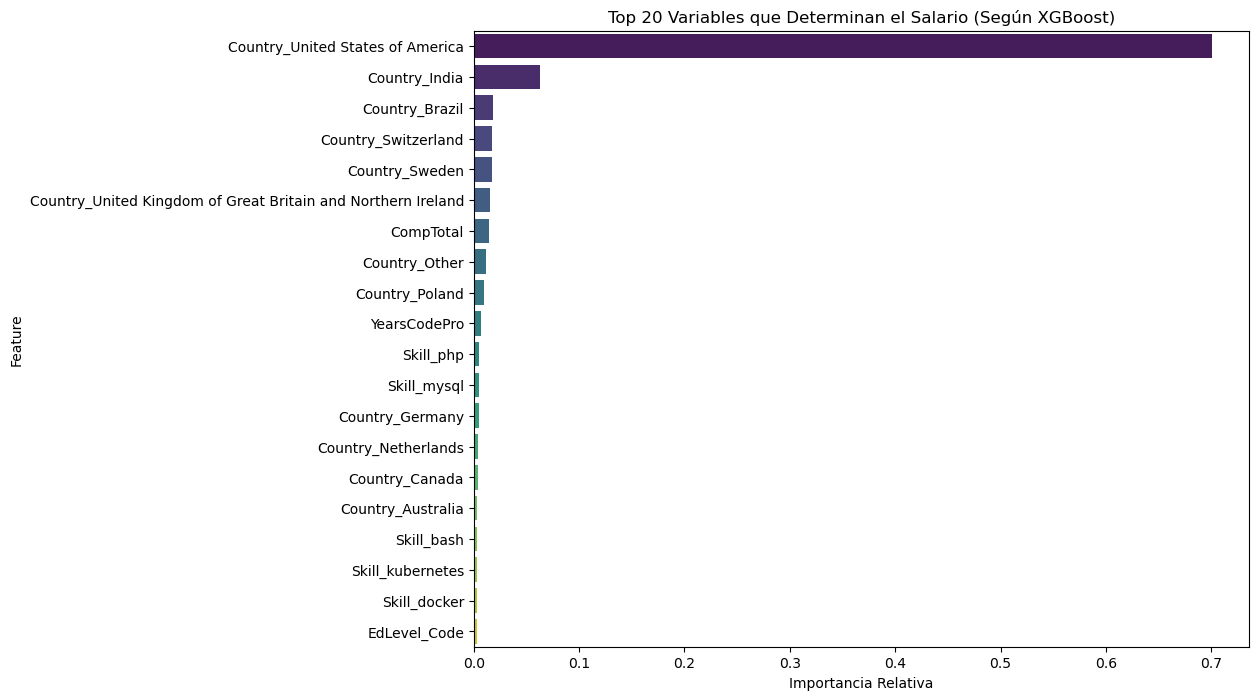

--- Top Habilidades Técnicas por Impacto Salarial ---
                      Feature  Importance
34                  Skill_php    0.005373
23                Skill_mysql    0.005323
22                 Skill_bash    0.003246
14           Skill_kubernetes    0.003007
16               Skill_docker    0.002889
27                  Skill_sas    0.002710
20               Skill_vmware    0.002550
3   Skill_amazon_web_services    0.002505
19           Skill_typescript    0.002236
24                Skill_scala    0.002147


In [14]:
import matplotlib.pyplot as plt

# Obtener la importancia de las variables
importances = model_xgb.feature_importances_
feature_names = X.columns

# Crear un DataFrame para visualizar mejor
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Graficar el Top 20
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Variables que Determinan el Salario (Según XGBoost)')
plt.xlabel('Importancia Relativa')
plt.show()

# Ver las top 5 habilidades específicamente
print("--- Top Habilidades Técnicas por Impacto Salarial ---")
print(feature_importance_df[feature_importance_df['Feature'].str.startswith('Skill_')].head(10))

In [15]:
def recomendar_mejoras_salariales(perfil_usuario, modelo, top_n=3):
    """
    perfil_usuario: Dict con los datos actuales del usuario (experiencia, país, skills actuales...)
    modelo: El modelo XGBoost entrenado
    top_n: Cuántas recomendaciones dar
    """
    import numpy as np
    
    # 1. Convertir el perfil del usuario al formato que espera el modelo (DataFrame de 1 fila)
    # (Aquí asumimos que 'perfil_usuario' ya viene preprocesado como una fila de X_test)
    X_actual = perfil_usuario.copy()
    
    # 2. Predecir salario actual
    log_pred_actual = modelo.predict(X_actual)[0]
    salario_actual_est = np.expm1(log_pred_actual)
    
    recomendaciones = []
    
    # 3. Identificar qué habilidades NO tiene el usuario
    # Buscamos columnas que empiecen por 'Skill_' y tengan valor 0
    skills_posibles = [col for col in X_actual.columns if col.startswith('Skill_') and X_actual[col].values[0] == 0]
    
    # 4. Simulación "What-If"
    print(f"Analizando {len(skills_posibles)} habilidades potenciales...")
    
    for skill in skills_posibles:
        # Crear una copia hipotética del perfil
        X_simulado = X_actual.copy()
        
        # SIMULAR: El usuario aprende esta habilidad (ponemos 1)
        X_simulado[skill] = 1
        
        # Predecir nuevo salario
        log_pred_nuevo = modelo.predict(X_simulado)[0]
        salario_nuevo_est = np.expm1(log_pred_nuevo)
        
        # Calcular ganancia
        diferencia = salario_nuevo_est - salario_actual_est
        
        if diferencia > 0:
            nombre_skill = skill.replace('Skill_', '').replace('_', ' ')
            recomendaciones.append({
                'Habilidad': nombre_skill,
                'Salario_Actual': salario_actual_est,
                'Salario_Proyectado': salario_nuevo_est,
                'Aumento_Estimado': diferencia
            })
    
    # 5. Ordenar por mayor aumento y devolver Top N
    recomendaciones_df = pd.DataFrame(recomendaciones).sort_values(by='Aumento_Estimado', ascending=False)
    return recomendaciones_df.head(top_n)

# --- PRUEBA RÁPIDA ---
# Tomemos un usuario al azar del set de prueba para probar la función
indice_prueba = 0
usuario_test = X_test.iloc[[indice_prueba]] # Doble corchete para mantenerlo como DataFrame

print(f"\n--- Simulando recomendaciones para un perfil de prueba ---")
resultados = recomendar_mejoras_salariales(usuario_test, model_xgb)
print(resultados)


--- Simulando recomendaciones para un perfil de prueba ---
Analizando 24 habilidades potenciales...
             Habilidad  Salario_Actual  Salario_Proyectado  Aumento_Estimado
0  amazon web services    40089.210938        48794.015625       8704.804688
4                react    40089.210938        47036.902344       6947.691406
3           kubernetes    40089.210938        45187.218750       5098.007812


In [16]:
import joblib

# --- 1. CORRECCIÓN FINAL: Eliminar 'CompTotal' (Data Leakage) ---
print("--- Eliminando variable de fuga de datos (CompTotal) ---")

# Lista actualizada de columnas a borrar
cols_prohibidas = [
    'CompTotal', 'CompFreq', # <--- ESTOS SON LOS CULPABLES
    'MainBranch', 'DevType', 'DevType_Grouped', 
    'ConvertedCompYearly', 'Log_ConvertedCompYearly',
    'LanguageHaveWorkedWith', 'All_Skills_Soup', 'All_Skills', 'All_Skills_Lower', 'All_Skills_Set',
    'Country', 'Country_Grouped', 'EdLevel', 'YearsCode', 'ResponseId', 'WorkExp', 'Currency'
]

# Filtrar columnas existentes
cols_borrar_reales = [c for c in cols_prohibidas if c in df_limpio.columns]

# Crear X final limpia
X_final = df_limpio.drop(columns=cols_borrar_reales)
X_final = X_final.select_dtypes(include=[np.number]) # Doble seguridad
y_final = df_limpio['Log_ConvertedCompYearly']

print(f"Features finales limpias: {X_final.shape[1]}")
# Verificar que CompTotal se fue
if 'CompTotal' not in X_final.columns:
    print("¡CompTotal eliminado exitosamente!")

# --- 2. Re-Entrenamiento Final (Train/Test Split) ---
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

print("\nEntrenando modelo DEFINITIVO (Honesto)...")
model_final = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    n_jobs=-1,
    random_state=42
)
model_final.fit(X_train, y_train)

# Evaluar
evaluar_rendimiento(model_final, X_test, y_test, "XGBoost Final (Sin Leakage)")

# --- 3. Guardar los Artefactos para la Web ---
print("\n--- Guardando archivos para la App Web ---")

# Guardamos el Modelo
joblib.dump(model_final, 'modelo_salarial_xgb.pkl')

# Guardamos las columnas exactas que usó el modelo (vital para crear el input en la web)
joblib.dump(X_final.columns.tolist(), 'model_features.pkl')

print("¡Archivos .pkl guardados! Listos para la Fase de Desarrollo Web.")

--- Eliminando variable de fuga de datos (CompTotal) ---
Features finales limpias: 69
¡CompTotal eliminado exitosamente!

Entrenando modelo DEFINITIVO (Honesto)...

>>> Modelo: XGBoost Final (Sin Leakage)
    R² Score: 54.18% (Explicación de varianza)
    Error Medio (MAE): $31,921 USD

--- Guardando archivos para la App Web ---
¡Archivos .pkl guardados! Listos para la Fase de Desarrollo Web.
